In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(ggridges))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(ggrepel))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

ips_order <- c('IPS_main', 'IPS_alt')
ips_hexes <- c('#1FB560', '#571B63')

tmp_times <- c('0', '1', '3', '5', '7', '9', '12', '14', '16', '18')
time_hexes <- c('#3B1F5E', '#5B2D8E', '#7B3FB0', '#3A6FB5', '#2E9AB5',
                '#27AE8F', '#2ECC71', '#F1C40F', '#E67E22', '#E84C3C')
names(time_hexes) <- tmp_times

umap_theme <- theme(
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: motif enrichment of early/mature-IPS differential peaks

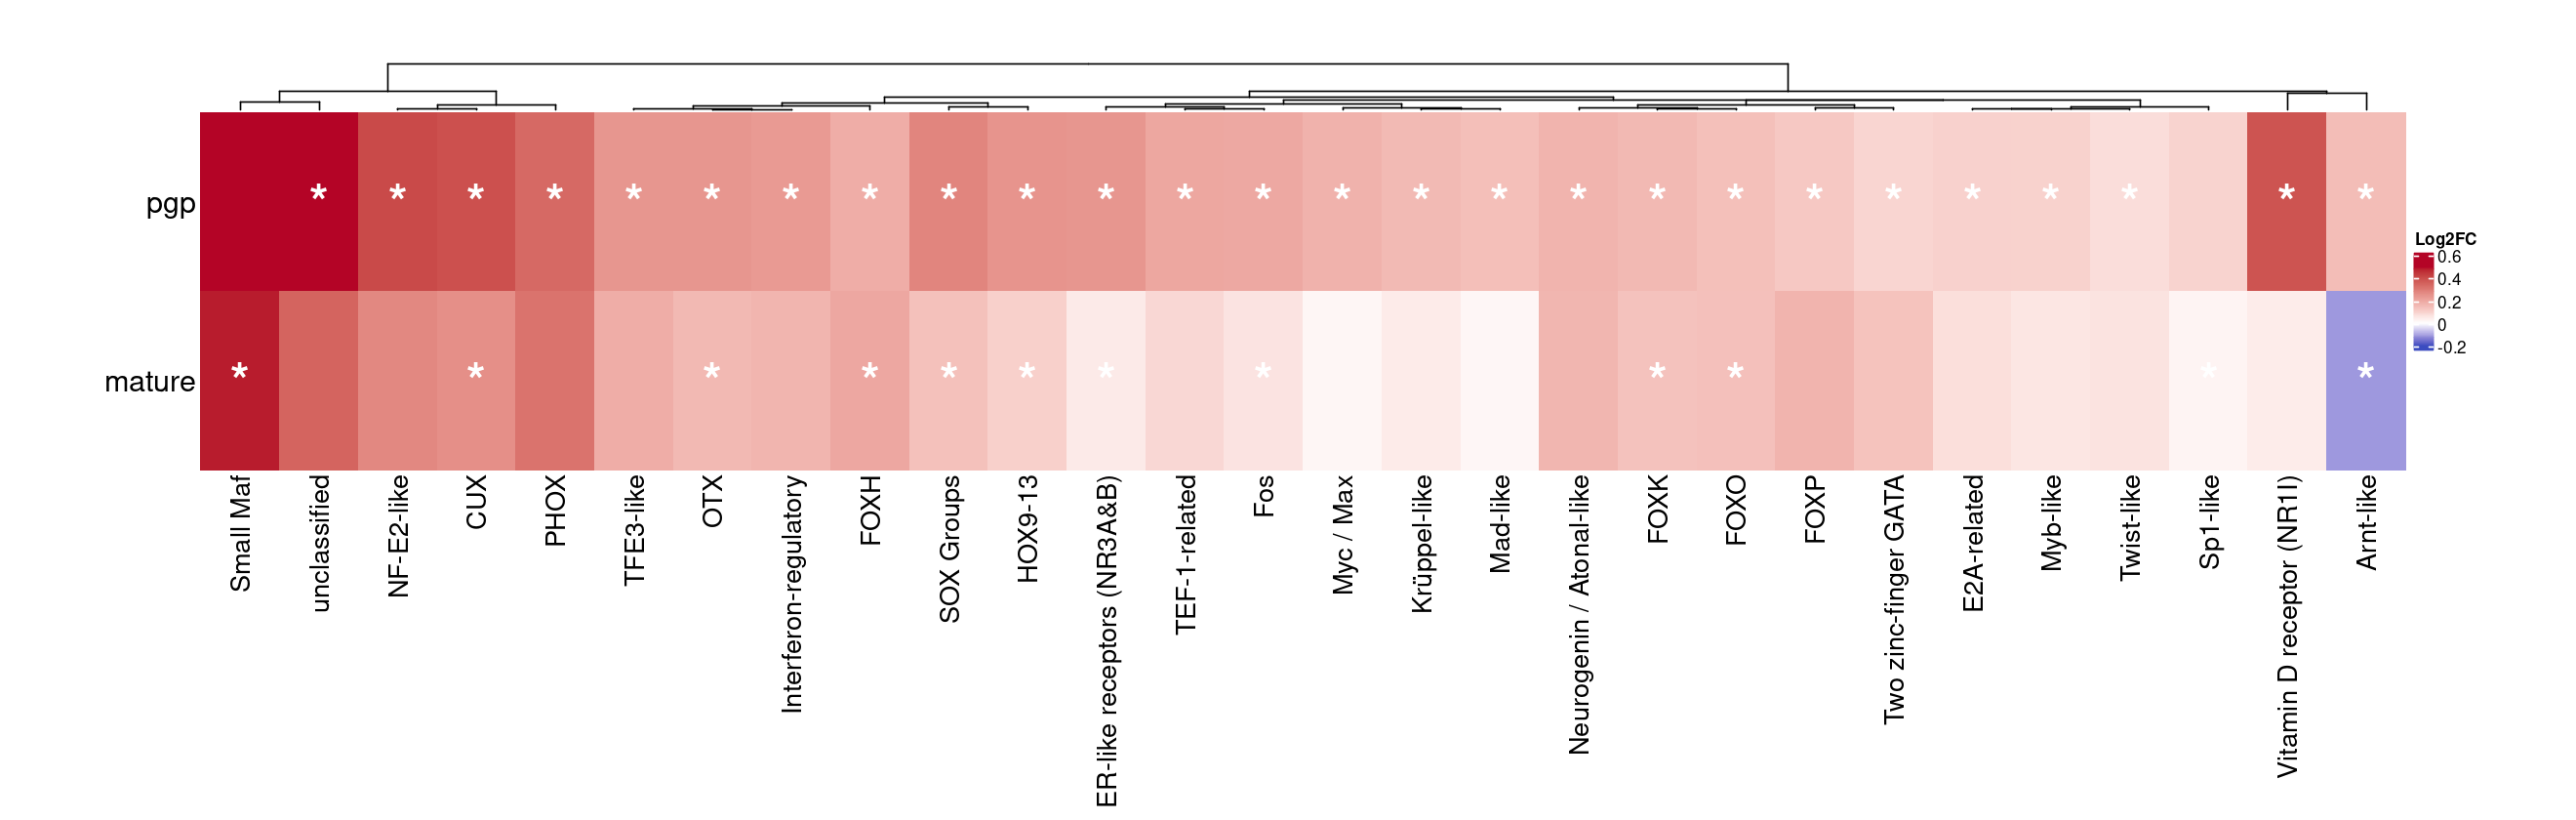

In [ ]:
motifs_path = paste0(projdir, '/csv/figure5/atac_mature_pgp_homer_clusters_fc.csv')
motifs = as.data.frame(fread(motifs_path, sep='\t'))
rownames(motifs) <- motifs$V1
motifs <- motifs[,-1]

fdr_path = paste0(projdir, '/csv/figure5/atac_mature_pgp_homer_clusters_pvals.csv')
fdr = as.data.frame(fread(fdr_path, sep='\t'))
rownames(fdr) <- fdr$V1
fdr <- fdr[,-1]

ht <- Heatmap(motifs,
              cluster_rows = TRUE,
              cluster_columns = TRUE)

row_ord <- row_order(ht)
col_ord <- column_order(ht)
fdr_ordered <- fdr[row_ord, col_ord]

thresh = 1e-5
tmp_fun <- function(j, i, x, y, w, h, fill) {
    if(!is.na(fdr_ordered[i, j]) && fdr_ordered[i, j] < thresh) {
        grid.text("*", x, y, gp = gpar(col = "white", fontsize = 30, fontface = "bold"))
    }
}

w = 22
h = 7
options(repr.plot.width=w, repr.plot.height=h)

ht <- Heatmap(motifs,
        name = "Log2FC",
        col = colorRamp2(c(-0.2, 0, 0.5), c("#3B4CC0", "white", "#B40426")),
        cluster_rows = FALSE,
        cluster_columns = TRUE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 18),
        column_names_gp = gpar(fontsize = 16, rot = 90),
        cell_fun=tmp_fun,
        heatmap_width = unit(50, "cm"),
        heatmap_height = unit(15, "cm"))

ht

### B: IPS-LE/IPS-SE per donor and day

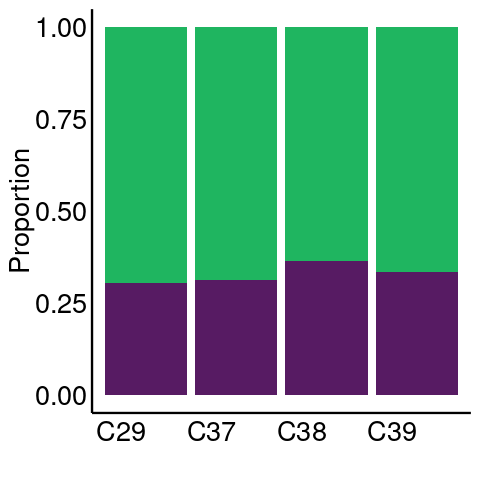

In [ ]:
df_path = paste0(projdir, '/csv/figure5/se_le_donor_prop.csv')
df = as.data.frame(fread(df_path, sep='\t'))
colnames(df) <- c('donor', 'IPS_LE', 'IPS_SE')

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

df_long <- pivot_longer(df, cols = c(IPS_LE, IPS_SE),
                         names_to = "subtype", values_to = "proportion")

ggplot(df_long, aes(x = donor, y = proportion, fill = subtype)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(x = "", y = "Proportion", fill = "") +
  theme_bw() +
  umap_theme +
  theme(
    axis.text.x = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.text.y = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=16, angle = 90, vjust=1, color='black'),
    axis.line.x = element_line(linewidth=0.5),
    axis.line.y = element_line(linewidth=0.5),
  ) +
  scale_fill_manual(values=ips_hexes)

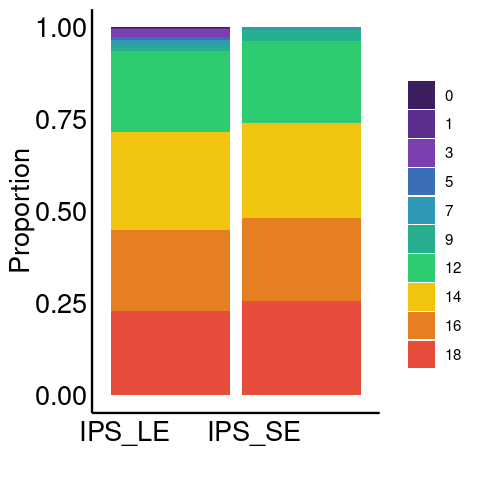

In [ ]:
df_path = paste0(projdir, '/csv/figure5/se_le_time_prop.csv')
df = as.data.frame(fread(df_path, sep='\t'))
colnames(df) <- c('time', 'IPS_LE', 'IPS_SE')

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

df_long <- pivot_longer(df, cols = c(IPS_LE, IPS_SE),
                         names_to = "subtype", values_to = "proportion")

ggplot(df_long, aes(x = subtype, y = proportion, fill = factor(time))) +
  geom_bar(stat = "identity", position = "stack") +
  labs(x = "", y = "Proportion", fill = "") +
  theme_bw() +
  umap_theme +
  theme(
    axis.text.x = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.text.y = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=16, angle = 90, vjust=1, color='black'),
    axis.line.x = element_line(linewidth=0.5),
    axis.line.y = element_line(linewidth=0.5),
    legend.position = 'right'
  ) +
  scale_fill_manual(values=time_hexes)

### C: 3C UMAP per donor, IPS-LE/IPS-SE

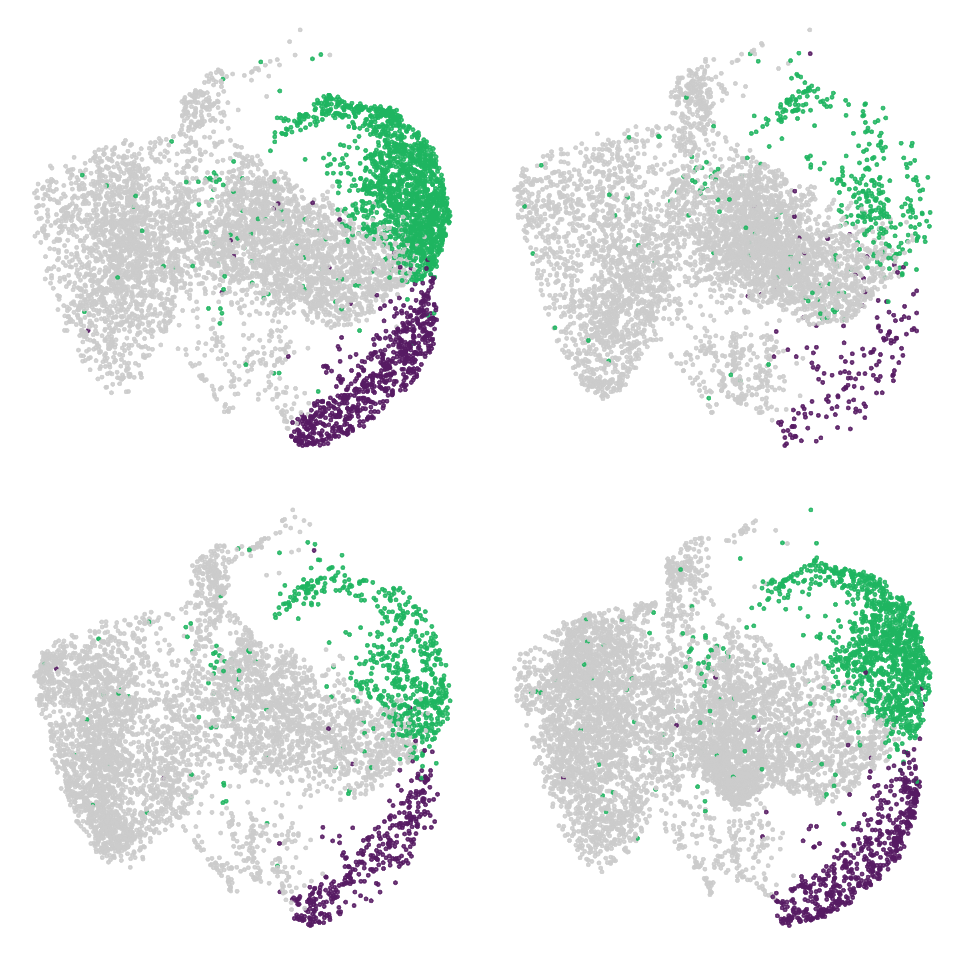

In [ ]:
hic_path = paste0(projdir, '/csv/figure2/hic_donor_umap.csv')
hic_umap = as.data.frame(fread(hic_path, sep='\t'))
hic_umap$donor <- factor(hic_umap$donor, levels=donors)
rownames(hic_umap) <- hic_umap$wellprefix

clusters_path <- '/u/project/cluo/terencew/igvf/2023_YR2/snmCT/mc/csv/label_transfer/xgboost_time_v7.csv'
clusters <- as.data.frame(fread(clusters_path, sep='\t'))
rownames(clusters) <- clusters$wellprefix
ips_clusters_path <- '/u/project/cluo/terencew/igvf/2023_YR2/snmCT/mc/csv/label_transfer/snm3c_ips_subtype.csv'
ips_clusters <- as.data.frame(fread(ips_clusters_path, sep='\t'))
rownames(ips_clusters) <- ips_clusters$V1
hic_umap$cluster <- clusters[hic_umap$wellprefix,]$cluster
hic_umap <- hic_umap[!is.na(hic_umap$cluster),]
hic_umap$cluster <- factor(hic_umap$cluster, levels=tmp_order)
hic_umap$ips_cluster <- ips_clusters[hic_umap$wellprefix,]$ips_subtype
hic_umap$ips_cluster[is.na(hic_umap$ips_cluster)] <- "other"
hic_umap$ips_cluster <- factor(hic_umap$ips_cluster, levels=ips_order)

plot_umap <- function(hic_umap, d) {
    mask <- hic_umap$donor == d
    tmp_umap <- hic_umap[mask,]
    ggplot(tmp_umap, aes(x = umap0, y = umap1, color = ips_cluster)) +
      geom_point_rast(alpha=0.8, size=0.5) +
      labs(x = "", y = "", color='IPS cluster') +
      theme_bw() +
      umap_theme +
       theme(
             legend.position = 'none') +
        scale_color_manual(values = ips_hexes, na.value = "grey80") +
              guides(color = guide_legend(override.aes = list(size = 4)))

}

set.seed(1)
shuffled_hic_umap <- hic_umap[sample(nrow(hic_umap)), ]

plot_list <- list()
for (i in seq_along(donors)) {
    d = donors[i]
    p <- plot_umap(shuffled_hic_umap, d)
    plot_list[[i]] <- p
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)

combined_plot <- plot_grid(plotlist=plot_list, nrow=2, ncol=2)
combined_plot

### D: methylation UMAP per donor, IPS-LE/IPS-SE

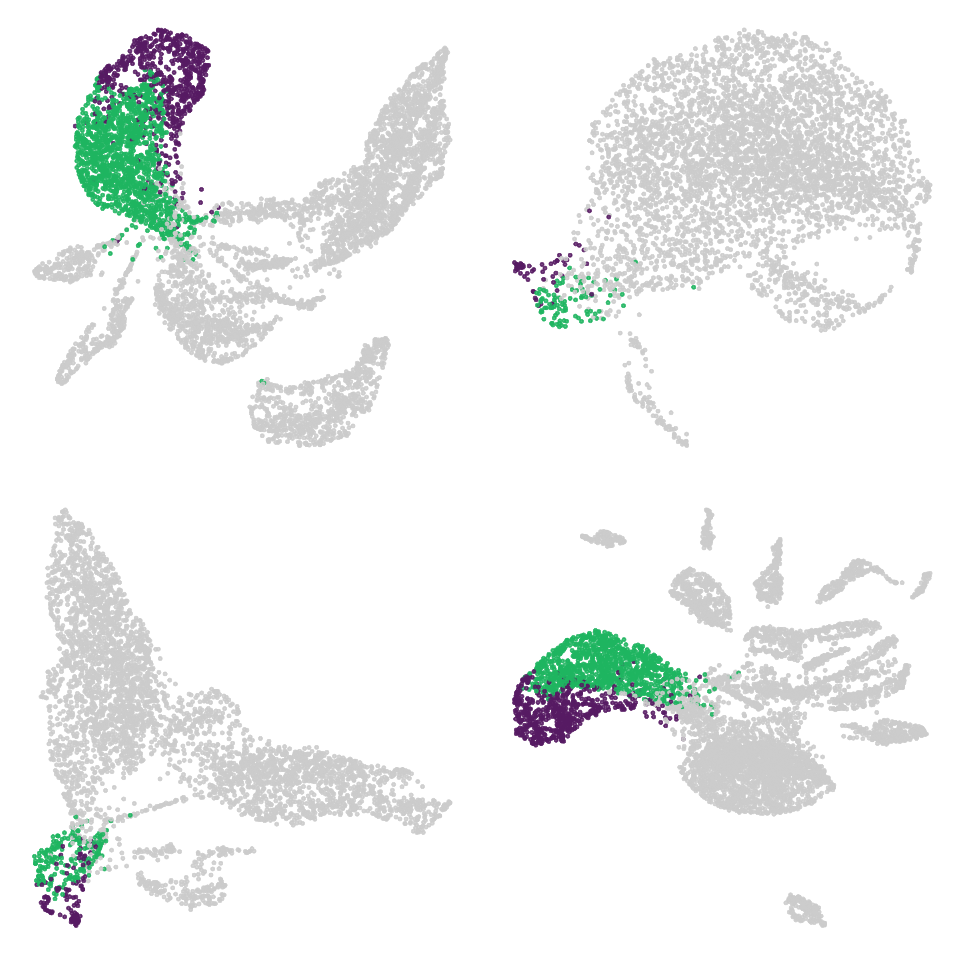

In [ ]:
mcg_umap_path = paste0(projdir, '/csv/figure5/snmct_snm3c_mcg_ips_subtype_umap_per_donor.csv')
mcg_umap = as.data.frame(fread(mcg_umap_path, sep='\t'))
mcg_umap$cluster <- factor(mcg_umap$cluster, levels=tmp_order)
mcg_umap$ips_subtype[mcg_umap$ips_subtype == ''] <- "other"
mcg_umap$ips_subtype <- factor(mcg_umap$ips_subtype, levels=ips_order)

plot_umap <- function(mcg_umap, d) {

  tmp_umap <- mcg_umap[mcg_umap$donor == d, ]

    ggplot(tmp_umap, aes(x = umap0, y = umap1, color = ips_subtype)) +
      geom_point_rast(alpha=0.8, size=0.5) +
      labs(x = "", y = "", color='IPS cluster') +
      theme_bw() +
      umap_theme +
       theme(legend.position = 'none') +
    scale_color_manual(values = ips_hexes, na.value = "grey80")
}

shuffled_mcg_umap <- mcg_umap[sample(nrow(mcg_umap)), ]

plot_list <- list()
for (i in seq_along(donors)) {
  d <- donors[i]

  plot_list[[i]] <- plot_umap(shuffled_mcg_umap, d)
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)

plot_grid(plotlist=plot_list, nrow=2, ncol=2)

### E: snmCT-seq RNA UMAP, IPS-LE/IPS-SE

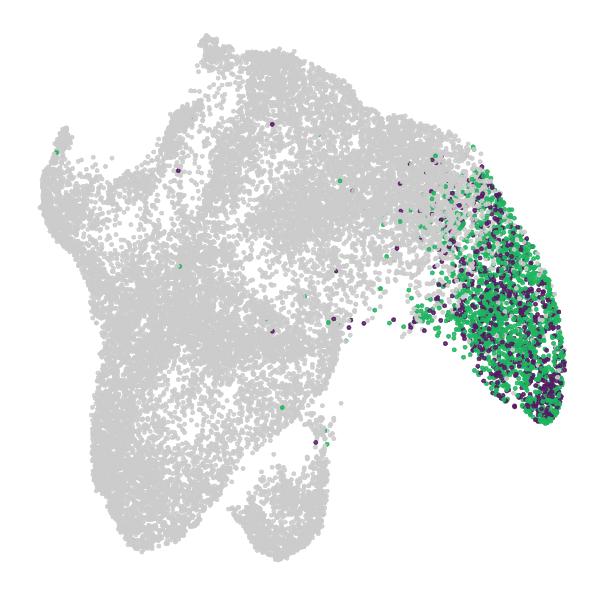

In [ ]:
rna_umap_path = paste0(projdir, '/csv/figure5/snmct_rna_ips_subtype_umap.csv')
rna_umap = as.data.frame(fread(rna_umap_path, sep='\t'))
rownames(rna_umap) <- rna_umap$V1
rna_umap$ips_subtype[rna_umap$ips_subtype == ''] <- "other"
rna_umap$ips_subtype <- factor(rna_umap$ips_subtype, levels=ips_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_rna_umap <- rna_umap[sample(nrow(rna_umap)), ]

ggplot(shuffled_rna_umap, aes(x = umap0, y = umap1, color = ips_subtype)) +
  geom_point_rast(alpha=0.8, size=0.5) +
  labs(x = "", y = "", color='IPS cluster') +
  theme_bw() +
  umap_theme +
   theme(legend.position = 'none') +
    scale_color_manual(values = ips_hexes, na.value = "grey80")

### F: pluripotency marker expression

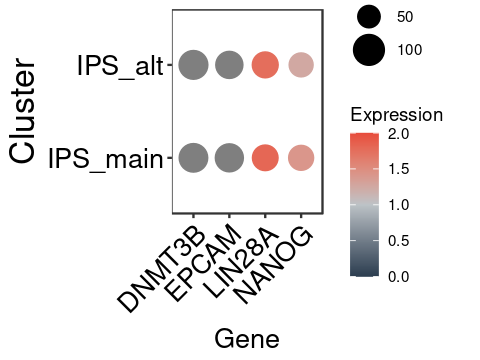

In [ ]:
ips_markers_path = paste0(projdir, '/csv/figure5/ips_subtypes_pluri_markers.csv')
ips_markers = as.data.frame(fread(ips_markers_path, sep='\t'))
ips_markers$ips_subtype <- factor(ips_markers$ips_subtype, levels=ips_order)

dot_df <- ips_markers %>%
  group_by(ips_subtype, variable) %>%
  summarise(
    avg_expr = mean(value),
    pct_expr = mean(value > 0) * 100,
    .groups = "drop"
  )

w = 4
h = 3
options(repr.plot.width=w, repr.plot.height=h)

ggplot(dot_df, aes(x = variable, y = ips_subtype)) +
  geom_point(aes(size = pct_expr, color = avg_expr)) +

  labs(x='Gene', y='Cluster', size = "% expressing", color = "Expression") +
  scale_color_gradientn(colors = c("#2c3e50", "#bdc3c7", "#e74c3c"), limits = c(0, 2)) +
  scale_size_area(max_size = 8, breaks = c(0, 50, 100), limits = c(0, 100)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size=16, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

### G: trajectory score per donor

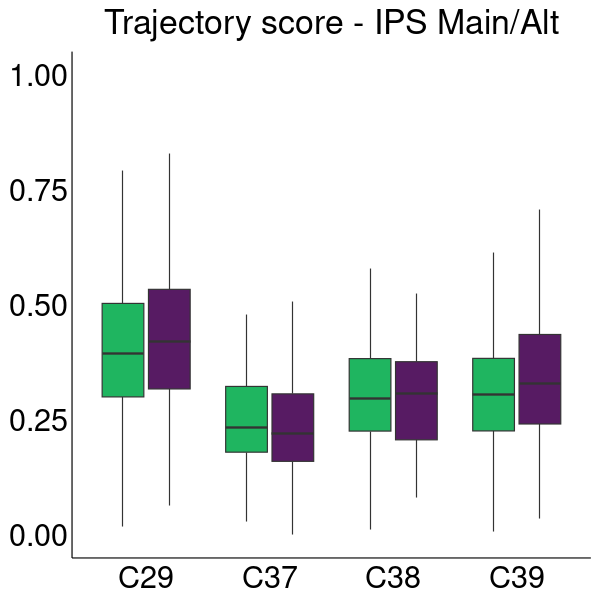

In [ ]:
rna_traj_path = paste0(projdir, '/csv/figure5/ips_subtype_rna_traj_score.csv')
rna_traj = read.csv(rna_traj_path, sep='\t')
rna_traj$cluster <- factor(rna_traj$cluster, levels=tmp_order)
rna_traj$ips_subtype <- factor(rna_traj$ips_subtype, levels=ips_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(rna_traj, aes(x = donor, y = traj_score, fill = ips_subtype)) +
  geom_boxplot(outlier.shape = NA, linewidth=0.25) +
  labs(x = "",y = "Score", title = "Trajectory score - IPS Main/Alt",
  ) +
  ylim(0, 1) +
  theme_bw() +
  umap_theme +
  theme(
    axis.text.x = element_text(size = 18, angle = 0, hjust = 0.5, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    plot.title = element_text(size = 20, hjust=0.5, color='black'),
    axis.line = element_line(linewidth=0.25),
    legend.position = "none") +
scale_fill_manual(values=ips_hexes)

### H: cell cycle scores per donor

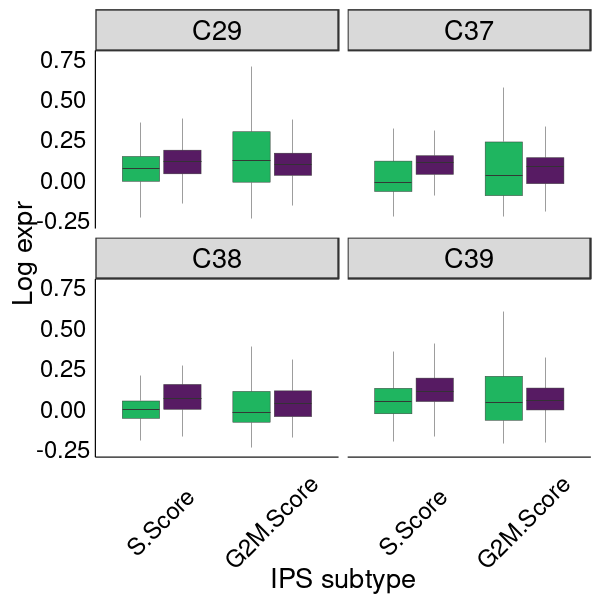

In [ ]:
cc_order <- c('S.Score', 'G2M.Score')

rna_cc_path = paste0(projdir, '/csv/figure5/ips_subtype_rna_cell_cycle.csv')
rna_cc = read.csv(rna_cc_path, sep='\t')
rna_cc$ips_subtype <- factor(rna_cc$ips_subtype, levels=ips_order)
rna_cc$variable <- factor(rna_cc$variable, levels=cc_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(rna_cc, aes(x = variable, y = value, fill = ips_subtype)) +
  geom_boxplot(outlier.shape=NA, linewidth=0.1) +
  labs(x = "IPS subtype", y = "Log expr", fill = 'Donor') +
  scale_y_continuous(limits = c(-0.25, 0.75)) +
  facet_wrap(~donor) +
  theme_bw() +
  umap_theme +
   theme(
        axis.text.x = element_text(size=14,angle=45, color='black', vjust=0.4),
        axis.text.y = element_text(size=14,angle=0, color='black'),
        strip.text = element_text(size=16, color='black'),
       axis.title.x = element_text(size=16,angle=0, color='black'),
        axis.title.y = element_text(size=16,angle=90, color='black', hjust=0.5),
         axis.line = element_line(linewidth=0.25)) +
    scale_fill_manual(values = ips_hexes)

### I: IPS-LE vs. IPS-SE DEGs

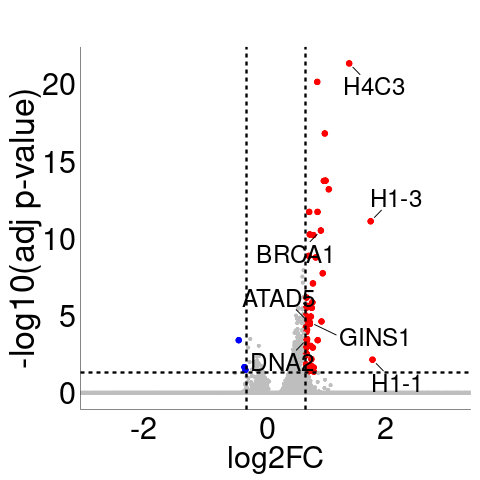

In [ ]:
degs_path <- '/u/project/cluo/terencew/igvf/2023_YR2/snmCT/rna/csv/degs/ips_subtypes/ips_alt.csv'
degs = as.data.frame(fread(degs_path, sep='\t'))

volcano_plot <- function(df, title = "", lfc_thresh = 0.5, pval_thresh = 0.05,
                          label_lfc_thresh = 1, label_pval_thresh = 0.01,
                          genes_of_interest = NULL) {

  df <- df %>%
    mutate(
      pvals_adj = ifelse(pvals_adj == 0, 1e-300, pvals_adj),
      neglog10_p = -log10(pvals_adj),
      sig = case_when(
        logfoldchanges >  lfc_thresh & pvals_adj < pval_thresh ~ "Up",
        logfoldchanges < -lfc_thresh & pvals_adj < pval_thresh ~ "Down",
        TRUE ~ "NS"
      )
    )

  ggplot(df, aes(x = logfoldchanges, y = neglog10_p)) +
    geom_point_rast(aes(color = sig, size = sig)) +

    coord_cartesian(xlim = c(-3, 3)) +
    geom_vline(xintercept = c(-lfc_thresh, lfc_thresh), linetype = "dashed") +
    geom_hline(yintercept = -log10(pval_thresh), linetype = "dashed") +

    geom_text_repel(
      data = df %>% filter(
        (sig != "NS" & abs(logfoldchanges) > label_lfc_thresh & pvals_adj < label_pval_thresh) |
        (names %in% genes_of_interest)
      ),
      aes(label = names),
      size = 5.0,
      max.overlaps = Inf,
      segment.size = 0.2,
      box.padding = 0.5,
      point.padding = 0.3,
      force = 2,
      force_pull = 0.5,
      max.iter = 20000,
      min.segment.length = 0,
      seed = 42
    ) +
    scale_color_manual(values = c("NS" = "grey", "Up" = "red", "Down" = "blue")) +
    scale_size_manual(values = c("NS" = 0.3, "Up" = 1, "Down" = 1)) +
    theme_bw() +
    umap_theme +
    theme(
        axis.text.x = element_text(size=18, angle = 0, hjust = 1, color='black'),
        axis.text.y = element_text(size=18, angle = 0, hjust = 1, color='black'),
        axis.line.x = element_line(linewidth=0.1, color='black'),
        axis.line.y = element_line(linewidth=0.1, color='black'),
        axis.title.x = element_text(size=18, angle = 0, vjust=0.5, color='black'),
        axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
        plot.title = element_text(size=18, angle = 0, hjust=0.5, color='black'),
         legend.position = 'none') +
    labs(
      title = title,
      x = "log2FC",
      y = "-log10(adj p-value)"
    )
}

final_genes <- c('ATAD5', 'DNA2', 'BRCA1', 'GINS1')

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)
volcano_plot(degs, genes_of_interest=final_genes)

### J: GO enrichment of DEGs

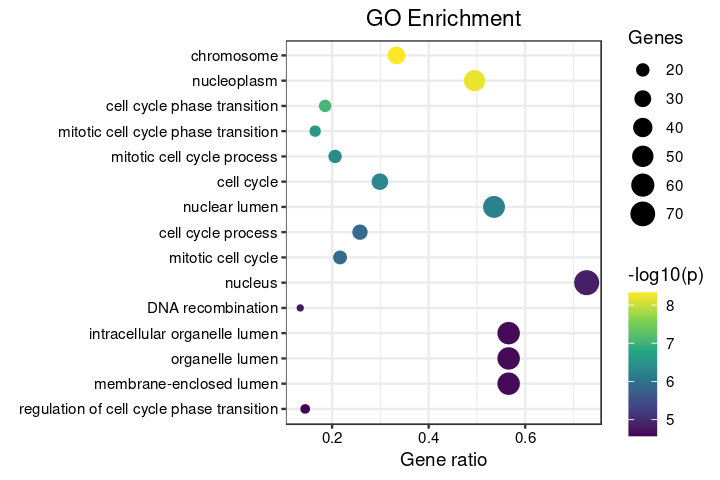

In [ ]:
ontology_path <- paste0(projdir, '/csv/figure5/ips_subtypes_go.csv')
ontology = as.data.frame(fread(ontology_path, sep='\t'))

plot_go_dot <- function(df, top_n = 15, title = "GO Enrichment") {

  df %>%
    mutate(
      p_value = ifelse(p_value == 0, 1e-300, p_value),
      neglog10_p = -log10(p_value),
      gene_ratio = intersection_size / query_size
    ) %>%
    arrange(p_value) %>%
    slice_head(n = top_n) %>%
    mutate(name = factor(name, levels = rev(name))) %>%

    ggplot(aes(x = gene_ratio, y = name)) +
    umap_theme +
    geom_point(aes(size = intersection_size, color = neglog10_p)) +
    scale_color_viridis_c() +
    labs(
      x = "Gene ratio",
      y = "",
      title = title,
      color = "-log10(p)",
      size = "Genes"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(color='black'),
        axis.text.y = element_text(color='black'),
            plot.title = element_text(color='black', hjust=0.5),

          )
}

w = 6
h = 4
options(repr.plot.width=w, repr.plot.height=h)

plot_go_dot(ontology)

### K: PMD metagene with mature-IPS

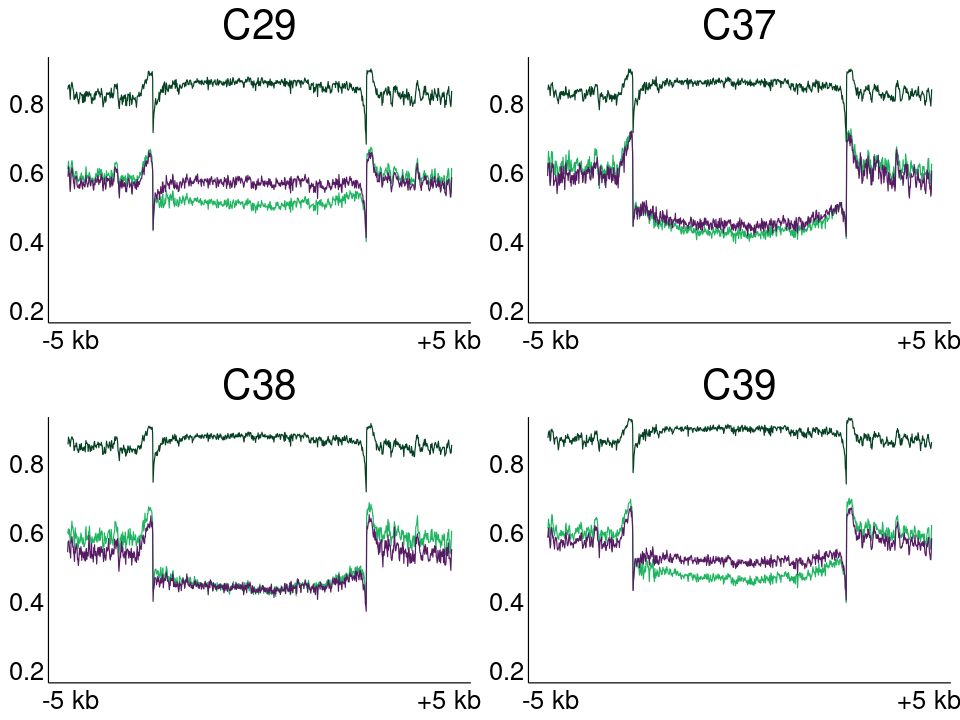

In [ ]:
pmds_metagene_path = paste0(projdir, '/csv/figure5/ips_cluster_donor_pmds_metagene.csv')
pmds_metagene = read.csv(pmds_metagene_path, sep='\t')
pmds_metagene$cluster <- factor(pmds_metagene$cluster, levels=ips_order)

slack = 6
tmp_breaks <- c(min(pmds_metagene$tmp) + slack, max(pmds_metagene$tmp) - slack)

final_ips_order <- c('IPS_main', 'IPS_alt', 'Mature-IPS')
final_ips_hexes <- c('#1FB560', '#571B63', '#064023')

mature_flank_path = paste0(projdir, '/csv/figure3/50_line_pmds_flank_metagene.csv')
mature_flank = as.data.frame(fread(mature_flank_path, sep='\t'))
mature_flank$donor <- factor(mature_flank$donor, levels=donors)
colnames(mature_flank) <- c('V1', 'mCG', 'tmp', 'sample', 'donor', 'cluster')
mask <- mature_flank$cluster == 'IPS'
mature_flank <- mature_flank[mask,]
mature_flank$cluster <- gsub('IPS', 'Mature-IPS', mature_flank$cluster)

pmds_metagene$mCG <- pmds_metagene$X0

select <- c('tmp', 'sample', 'donor', 'cluster', 'mCG')
final_metagene <- pmds_metagene[select]
final_mature <- mature_flank[select]
final_flank <- rbind(final_metagene, final_mature)
final_flank$donor <- factor(final_flank$donor, levels=donors)
final_flank$cluster <- factor(final_flank$cluster, levels=final_ips_order)

plot_pmds <- function(pmds, d) {

    mask <- pmds$donor == d
    tmp_pmds <- pmds[mask,]

    ggplot(tmp_pmds, aes(x = tmp, y = mCG, color = cluster, group = cluster)) +
      geom_line(linewidth = 0.25) +
    labs(x = "Position", y = "mCG", title=d) +
     coord_cartesian(ylim = c(0.2, 0.9)) +
        scale_x_continuous(breaks = tmp_breaks, labels = c("-5 kb", "+5 kb")) +
      theme_bw() +
      umap_theme +
       theme(axis.text.x = element_text(size=15, color='black'),
            axis.text.y = element_text(size=15, color='black'),
            plot.title = element_text(size=24, hjust=0.5),
            axis.line = element_line(size=0.25),
             legend.position = 'none') +
            scale_color_manual(values = final_ips_hexes)
}

plot_list = list()

for (i in seq_along(donors)) {
    d <- donors[i]
    plot_list[[i]] <- plot_pmds(final_flank, d)
}
w = 8
h = 6
options(repr.plot.width=w, repr.plot.height=h)

plot_grid(plotlist = plot_list, ncol=2, nrow=2)

### L: compartment score correlation with mature-IPS

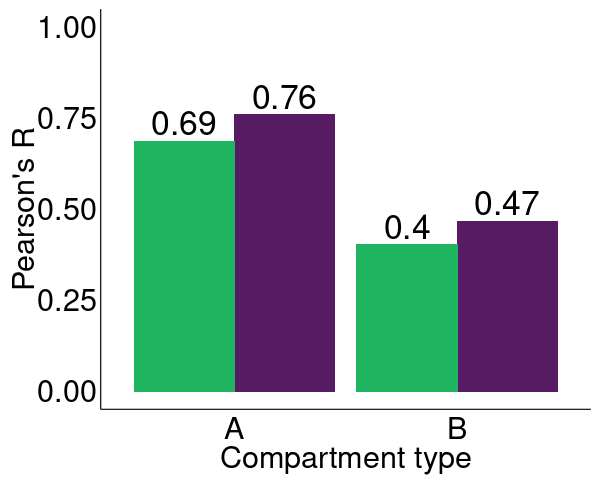

In [ ]:
pub_eigs_path = paste0(projdir, '/csv/figure5/4dn_mature_ips_eigenvector_corr.csv')
pub_eigs = as.data.frame(fread(pub_eigs_path, sep='\t'))
pub_eigs <- as.data.frame(pub_eigs[,-1])
pub_eigs$variable <- factor(pub_eigs$variable, levels=ips_order)

w = 5
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pub_eigs, aes(x = comp, y = value, fill = variable)) +
  geom_bar(position='dodge', stat='identity') +
  geom_text( aes(label = round(value, 2)),
    position = position_dodge(width = 0.9), vjust = -0.25, size = 7) +
labs(x = "Compartment type",y = "Pearson's R") +
  ylim(0, 1) +
  theme_bw() +
  umap_theme +
  theme(
    axis.text.x = element_text(size = 18, angle = 0, hjust = 0.5, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title.x = element_text(size = 18, color='black'),
    axis.title.y = element_text(size = 18, angle=90, color='black'),
    plot.title = element_text(size = 20, hjust=0.5, color='black'),
    axis.line = element_line(linewidth=0.25),
         legend.position = 'none') +
    scale_fill_manual(values=ips_hexes)

### M: TAD boundary frequency

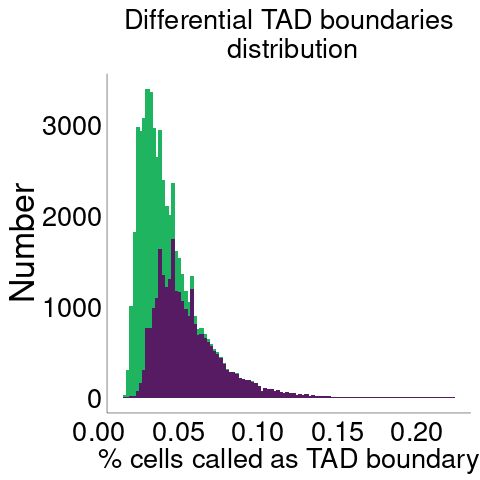

In [ ]:
tad_dist_path <- paste0(projdir, '/csv/figure5/ips_subtypes_tad_dist.csv')
tad_dist = as.data.frame(fread(tad_dist_path, sep='\t'))
tad_dist$variable <- gsub('_frac', '', tad_dist$variable)
tad_dist$variable <- factor(tad_dist$variable, levels=ips_order)

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(tad_dist, aes(x = value, fill = variable)) +
  geom_histogram(binwidth=0.002) +
  labs(x='% cells called as TAD boundary', y='Number', title='Differential TAD boundaries\n distribution')  +
  theme_bw() +
  umap_theme +
  theme(
    axis.text.x = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.text.y = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.line.x = element_line(linewidth=0.1, color='black'),
    axis.line.y = element_line(linewidth=0.1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    plot.title = element_text(size=16, angle = 0, hjust=0.5, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  ) +
  scale_fill_manual(values=ips_hexes)

### N: GREAT GO terms of differential TAD boundaries

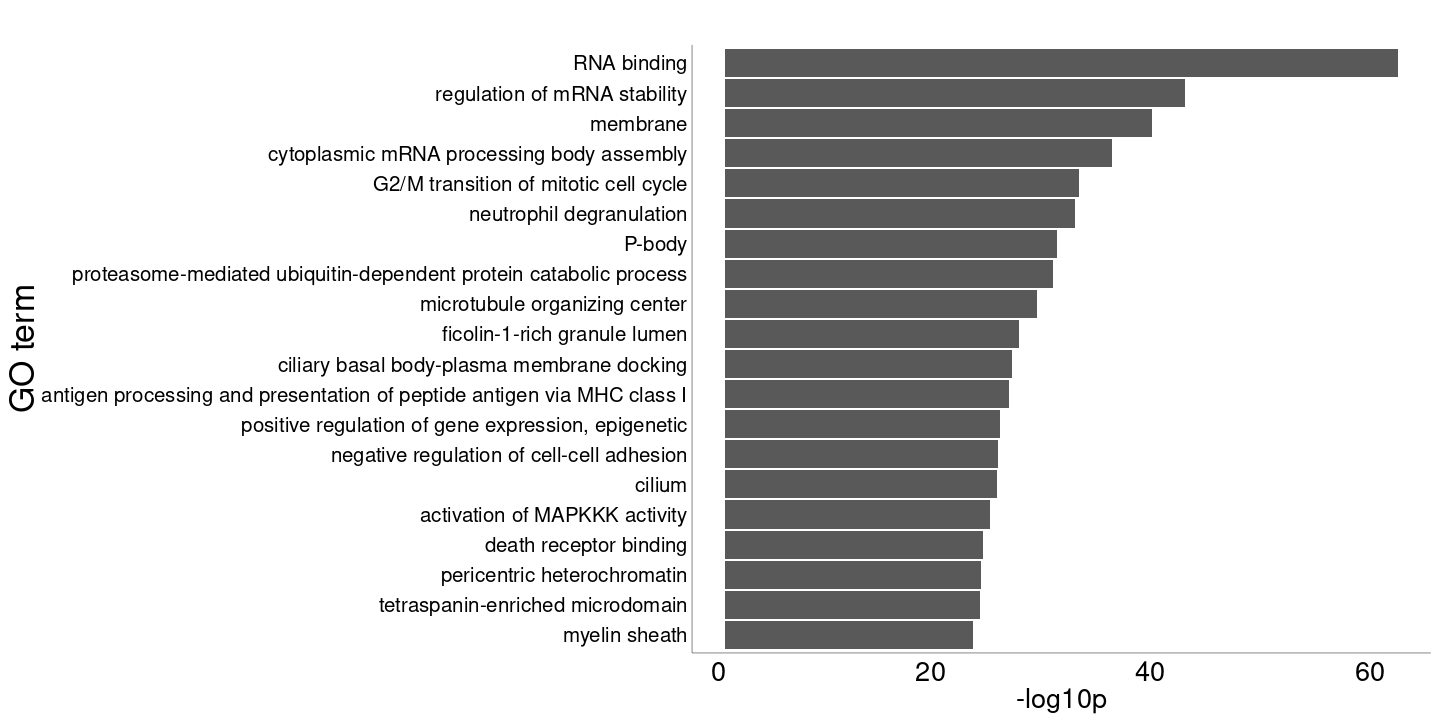

In [ ]:
great_path <- paste0(projdir, '/csv/figure5/ips_subtypes_tads_great.csv')
great = as.data.frame(fread(great_path, sep='\t'))
great$go_term <- factor(great$go_term, levels=rev(great$go_term))
great <- great[1:20,]

w = 12
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ggplot(great, aes(x = neg_log10p, y = go_term)) +
  geom_bar(stat='identity', position='dodge') +
  labs(x='-log10p', y='GO term', title='')  +
  theme_bw() +
  umap_theme +
  theme(
    axis.text.x = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.text.y = element_text(size=12, angle = 0, hjust = 1, color='black'),
    axis.line.x = element_line(linewidth=0.1, color='black'),
    axis.line.y = element_line(linewidth=0.1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    plot.title = element_text(size=16, angle = 0, hjust=0.5, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

In [ ]:
sessionInfo()

In [ ]:
Sys.time()